# Visión por Computador - Práctica 2 - Deep Learning en Computer Vision

#### 15 puntos   |   Fecha de entrega: 7 de Diciembre, 23:59   |   Forma de entrega: a través de la tarea creada en https://pradogrado2526.ugr.es/

### Estudiante: <mark>Leandro Jorge Fernández Vega</mark>

## Normas de desarrollo y entrega de la práctica

1. Para este trabajo, al igual que para los demás, se debe presentar código, resultados, discusión de los mismos, y presentación y análisis del trabajo realizado, todo integrado en el propio Google Colab Notebook (es decir, no se entrega ninguna memoria separada en `.pdf` ni ningún código `.py`). Se recuerda que código y resultados sin informe explicativo no puntúa. Resulta también fundamental recordar que solo se acepta la entrega de ficheros `.ipynb` (no resulta válido entregar un fichero `.py`).

2. En relación con el punto anterior, se recuerda que se proporciona un Notebook, denominado `Ejemplo_Otsu.ipynb`, que muestra un ejemplo de respuesta y solución a un potencial ejercicio. El propósito de este Notebook es servir de referencia al alumnado acerca de cómo responder los ejercicios planteados. Véase que, por ejemplo, en aras de diferenciar con facilidad enunciados y respuestas, estas últimas se presentan en otro color (azul, en ese caso).

3. El diseño de celdas del documento debe ser respetado. Es decir, no se puede modificar el orden de los ejercicios o alterar la estructura del Notebook, de forma que dificulte localizar los contenidos. Aunque sí se puede, por ejemplo, crear nuevas subsecciones dentro de las secciones ya existentes para estructurar y organizar con más claridad las respuestas, así como para incluir los experimentos extra que se deseen.

4. Tal y como se muestra en `Ejemplo_Otsu.ipynb`, no hay ningún problema en emplear técnicas de IA generativa (como ChatGPT o Gemini) para crear el código de los distintos ejercicios o para enriquecer el análisis y descripción del trabajo realizado (aunque, obvia decirlo, su uso no es obligatorio). Pero, en caso de usarse, sí se debe aclarar de qué modo se ha usado la IA, con qué objetivo, y se debe demostrar que se entiende perfectamente lo que se ha hecho.

5. Solo se entregará el fichero `.ipynb` (incorporando código, resultados, y explicación del trabajo realizado y los resultados obtenidos) y no se enviarán las imágenes empleadas. El path para la lectura de imágenes, o cualquier otro fichero de entrada, debe ser siempre “/content/drive/My Drive/images/nombre_fichero”.

6. El código deberá  presentarse adecuadamente comentado y con los resultados obtenidos en cada apartado, junto con la presentación del trabajo realizado y la discusión y análisis de los resultados obtenidos. Es importante reiterar que la entrega de código sin informe explicativo o valoraciones no puntúa. Por otro lado, el código debe ir comentado en comentarios en celdas de código, mientras que el análisis y discusión, tanto del trabajo realizado como de los resultados obtenidos, debe ir en celdas de texto.






### Materiales de Apoyo

En caso de que el alumnado tenga dudas sobre Python, OpenCV o el uso de Google Colab, se recuerda que en PRADO hay materiales de apoyo (https://pradogrado2526.ugr.es/mod/folder/view.php?id=95307):
-  Introducción a Python: https://pradogrado2526.ugr.es/pluginfile.php/243163/mod_folder/content/0/1.%20Introduccion%20a%20Python.pdf
- Introducción a NumPy, Matplotlib y Scikit-learn: https://pradogrado2526.ugr.es/pluginfile.php/243163/mod_folder/content/0/2.%20Introducción%20a%20Numpy%20Matplotlib%20y%20sklearn.pdf
- Notebook con toda la información anterior (y más cosas): https://pradogrado2526.ugr.es/pluginfile.php/243163/mod_folder/content/0/Guia_Python.ipynb
- Ejercicios y ejemplos de repaso: https://pradogrado2526.ugr.es/pluginfile.php/243163/mod_folder/content/0/3.%20Ejercicios%20y%20ejemplos%20de%20repaso.pdf
- Fundamentos de Python para lectura, visualización y manipulación de imágenes: https://pradogrado2526.ugr.es/pluginfile.php/243163/mod_folder/content/0/4.%20Fundamentos%20de%20Python%20para%20manipulacion%20de%20imagenes.pdf (y Notebook asociado: https://pradogrado2526.ugr.es/pluginfile.php/243163/mod_folder/content/0/Guia_fundamentos_imagenes.ipynb)
- Ideas sobre cómo redactar un documento académico-científico (útil para saber cómo documentar las respuestas a los ejercicios, el Notebook en su conjunto, y la memoria del proyecto final o de un TFG/TFM): https://pradogrado2526.ugr.es/pluginfile.php/243163/mod_folder/content/0/Algunas%20ideas%20sobre%20cómo%20elaborar%20un%20informe%20académico-científico.pdf
- Ejemplo de respuesta a un hipotético ejercicio sobre el algoritmo de umbralización de Otsu: https://pradogrado2526.ugr.es/pluginfile.php/243164/mod_folder/content/0/Ejemplo_Otsu.ipynb

# **Ejercicio  3: Transfer Learning y fine-tuning con ResNet34 en el SPR X-Ray Age Prediction Challenge (4 points)**
En este ejercicio trabajaremos con el _SPR X-Ray Age Prediction Challenge_ de Kaggle (https://www.kaggle.com/competitions/spr-x-ray-age/data). Este dataset consta de $10 702$ radiografías de tórax, y el objetivo es predecir la edad de la persona a partir de la imagen de la radiografía. En esta ocasión, se emplearán $6 702$ imágenes para entrenamiento y $4 000$ para test. Las edades oscilan entre los 18 y los 89 años. Para facilitar el trabajo al alumnado se proporciona una versión procesada de los datos (con resolución $224\times224$, en lugar de $1024\times1024$, y empleando solo ejemplos para los cuales se tiene salida deseada (dado que, al tratarse de una challenge de kaggle, el conjunto de test está disponible pero sin etiquetar)). Estos datos se pueden acceder desde: https://drive.google.com/drive/folders/1hCWfTLs1w0h5kObl6NEIhEtH5VDmmCnj?usp=sharing (se debe emplear una cuenta de la UGR para acceder a dicha URL, y la información allí contenida (directorio `spr-x-ray-age`) se debe incluir en la carpeta `Colab Notebooks`).

Se debe emplear un $20\%$ de los datos de entrenamiento para validación, y el rendimiento debe ser evaluado, como mínimo, por medio de $MSE$, $MAE$ y $R^2$ _(coefficient of determination) score_. Se deben justificar las decisiones tomadas, como la elección de la función de pérdida. Del mismo modo, es necesario hacer un `summary()` de las arquitecturas empleadas en cada apartado, indicando qué parámetros/capas/bloques son entrenables y cuáles no lo son (es decir, en cada apartado es imprescindible destacar claramente qué arquitectura exacta se está utilizando, así como qué pesos se están entrenando y cuáles se están congelando).

Usaremos un modelo ResNet34 pre-entrenado en ImageNet, y tendremos que realizar los experimentos, y responder las preguntas, que se muestran a continuación:
  
  1. (0.75 puntos) Partimos de ResNet34, adaptamos la cabecera (sustituyendo la cabecera anterior por *una única fully-connected* con el número de neuronas de salida adecuado), y reentrenamos (_from scratch_) la red entera para este nuevo problema durante $15$ épocas. Es decir, partimos de pesos aleatorios para resolver este problema de regresión.

  

  2.  (1.25 puntos) Partimos de ResNet34, adaptamos la cabecera (empleando la misma del apartado anterior), y entrenamos solo la cabecera incorporada. Es decir, ResNet34 se usa como un mero extractor de características (preentrenado en ImageNet), y los pesos que se entrenan  durante $15$ épocas son los de la nueva capa incorporada (manteniendo fijos/congelados todos los demás). Como parte de este apartado se deben responder las dos siguientes preguntas:
  
      -  (0.25 puntos) Si no se especifica ninguna `custom_head`, ¿qué incorpora fastai por defecto?
      -  (0.25 puntos) Estamos intentando resolver un problema de regresión por medio de la reutilización de un modelo pre-entrenado en un problema de clasificación (ImageNet). ¿Tiene sentido hacerlo? ¿Por qué nos sirven pesos entrenados en clasificación para un problema de regresión? ¿No son, acaso, problemáticas muy diferentes?

  

  3. (1 punto) Partimos de ResNet34, empleamos la cabecera del apartado anterior, y hacemos un ajuste fino de toda la red partiendo de los pesos de ResNet34 (preentrenada en ImageNet) durante $15$ épocas: $5$ para la cabecera y $10$ para toda la red. En base a toda la experimentación realizada hasta ahora en los tres apartados:

      - (0.25 puntos) ¿Qué conclusiones se pueden extraer? En caso de que nos enfrentemos a un nuevo problema, ¿qué opción, u opciones, de entre las anteriores, parece a priori la más razonable? ¿Por qué?

4. (1 punto) Partimos de ResNet34, empleamos la cabecera del apartado anterior, y hacemos un ajuste fino de toda la red partiendo de los pesos de ResNet34 (preentrenada en ImageNet) durante $15$ épocas: $5$ para la cabecera y $10$ para toda la red. Pero, en este caso, enfocamos el problema como uno de clasificación con tantas clases como años contiene nuestro dataset ($[18, 89]$). El alumnado debe emplear, al menos, dos métricas de clasificación para evaluar el rendimiento. ¿Qué conclusiones extrae de este experimento? ¿Qué aproximación, a priori, parece más adecuada: regresión o clasificación?

Nota: en todo el enunciado de este ejercicio, cuando se habla de sustituir la cabecera "por una única fully-connected con el número de neuronas de salida adecuado", se trata de hacer eso literalmente (como máximo se puede añadir una capa de flattening, pero no se pueden usar capas de pooling).

In [ ]:
!pip install -U "fastai==2.7.15" "fastcore==1.5.29" "fastprogress==1.0.3" "fastdownload==0.0.7"
from fastai.vision.all import *
import pandas as pd
import os
from sklearn.metrics import r2_score

INFO: pip is looking at multiple versions of torchvision to determine which version is compatible with other requirements. This could take a while.
INFO: pip is still looking at multiple versions of torchvision to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 232.7/232.7 kB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.6/67.6 kB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 779.1/779.1 MB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 410.6/410.6 MB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.1/14.1 MB 129.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.7/23.7 MB 111.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 823.6/823.6 kB 55.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 731.7/731.7 MB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.6/121.6 MB 

In [ ]:
# # We start by getting access to the drive
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


## **Auxiliar Functions**

In [ ]:
# Function to display evaluation metrics
# Developed by Ignacio Oguiza: https://forums.fast.ai/t/plotting-metrics-after-learning/69937

@patch
@delegates(subplots)
def plot_metrics(self: Recorder, nrows=None, ncols=None, figsize=None, **kwargs):
    metrics = np.stack(self.values)
    names = self.metric_names[1:-1]
    n = len(names) - 1
    if nrows is None and ncols is None:
        nrows = int(math.sqrt(n))
        ncols = int(np.ceil(n / nrows))
    elif nrows is None: nrows = int(np.ceil(n / ncols))
    elif ncols is None: ncols = int(np.ceil(n / nrows))
    figsize = figsize or (ncols * 6, nrows * 4)
    fig, axs = subplots(nrows, ncols, figsize=figsize, **kwargs)
    axs = [ax if i < n else ax.set_axis_off() for i, ax in enumerate(axs.flatten())][:n]
    for i, (name, ax) in enumerate(zip(names, [axs[0]] + axs)):
        ax.plot(metrics[:, i], color='#1f77b4' if i == 0 else '#ff7f0e', label='valid' if i > 0 else 'train')
        ax.set_title(name if i > 1 else 'losses')
        ax.legend(loc='best')
    plt.show()

In [ ]:
def show_results(dls,learner,mode):
  """Displays confusion matrix and accuracy for a given mode (Train, Valid, Test).

  Args:
    dls: The DataLoaders object containing train, valid, and test data.
    learner: The Learner object with the trained model.
    mode: A string indicating the dataset to evaluate ('Train', 'Valid', or 'Test').
  """

  if mode=='Train':
    dl=dls.train
  elif mode=='Validation':
    dl=dls.valid
  elif mode=='Test':
    test_path = path/'test'
    test_files = [fn for fn in sorted(test_path.glob('**/*')) if fn.is_file()]
    dl = learner.dls.test_dl(test_files,with_labels=True, device='cuda') # Test set also normalized the same way

  # Confusion Matrix
  interp = ClassificationInterpretation.from_learner(learner, 1, dl)
  cm = interp.confusion_matrix()
  print(f'Number of {mode} Examples:', np.sum(cm))
  interp.plot_confusion_matrix(figsize=(12, 12),title=f'Confusion Matrix for the {mode} Set')

  # Accuracy
  acc= np.sum(np.diagonal(cm))/np.sum(cm)*100
  print(f'{mode} Accuracy: {acc}%')

In [ ]:
#!ls gdrive/MyDrive/Colab\ Notebooks/spr-x-ray-age/
!ls /content/drive/MyDrive/Colab\ Notebooks/spr-x-ray-age/


#%cd /content
#%pwd
#!ls /content/drive

#!ls '/content/drive/MyDrive/Colab Notebooks/VC/images/spr-x-ray-age/'


/content
MyDrive  Shareddrives
All_labels.csv	test  train


In [ ]:

train_folder = 'drive/MyDrive/Colab Notebooks/spr-x-ray-age/train'
test_folder = 'drive/MyDrive/Colab Notebooks/spr-x-ray-age/test'
csv_path = 'drive/MyDrive/Colab Notebooks/spr-x-ray-age/All_labels.csv'


#train_folder = 'drive/MyDrive/Colab Notebooks/VC/images/spr-x-ray-age/train'
#test_folder = 'drive/MyDrive/Colab Notebooks/VC/images/spr-x-ray-age/test'
#csv_path = 'drive/MyDrive/Colab Notebooks/VC/images/spr-x-ray-age/All_labels.csv'

In [ ]:
if os.path.exists(csv_path):
    print("CSV File exists!")
    # reading the labels dataframe
    df = pd.read_csv(csv_path, dtype=float, index_col=0)
    print(f'Dataframe shape: {df.shape}')
else:
    print("File does not exist.")

CSV File exists!
Dataframe shape: (10702, 1)


In [ ]:
# defining the dataset paths
train_path = Path(train_folder)
test_path = Path(test_folder)

# reading the folders looking for images
train_files = get_image_files(train_path)
test_files = sorted(get_image_files(test_path))

print(f'{len(train_files)} files were found for training and {len(test_files)} files were found for test')

6702 files were found for training and 4000 files were found for test


Age varies from 18.0 to 89.0



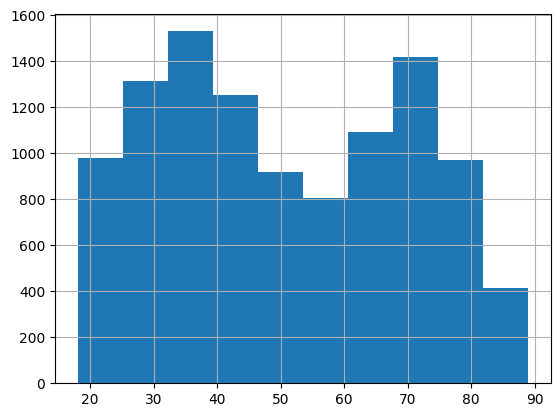

In [ ]:
print(f'Age varies from {df.age.min()} to {df.age.max()}\n')
_=df.age.hist()

In [ ]:
# function used to return the label from an image
def label_func(file):
    # takes the file's base name w/o the extension
    basename = int(os.path.basename(str(file)).split('.')[0])

    # searches for the label
    label = int(df.age[basename])

    return label

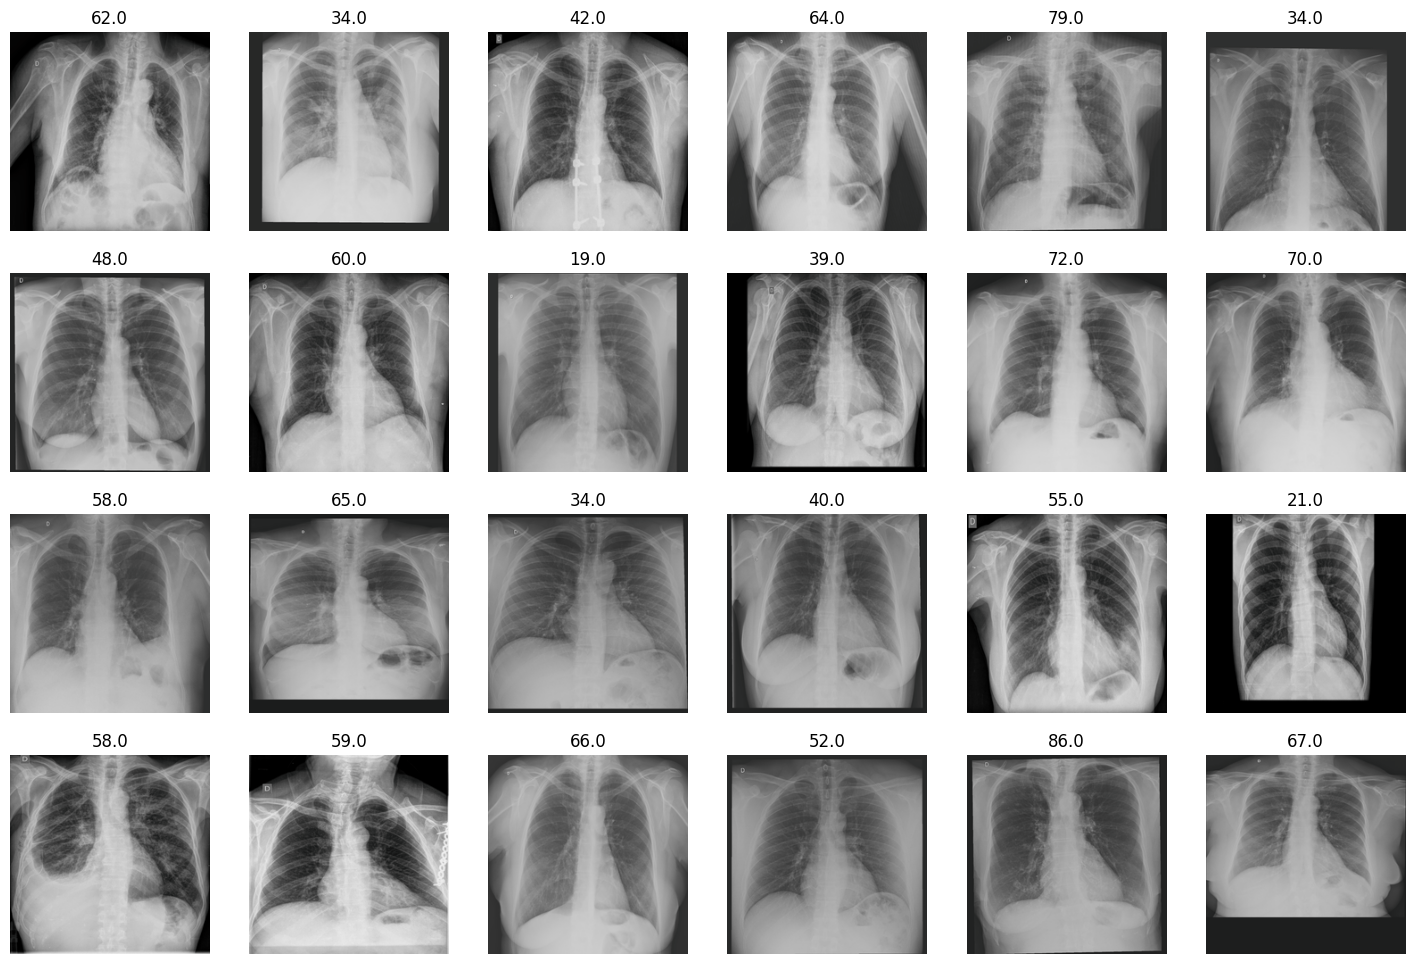

In [ ]:
dtblk = DataBlock(

    blocks=(ImageBlock, RegressionBlock), # RegressionBlock for age prediction
    get_items=get_image_files,
    splitter=RandomSplitter(valid_pct=0.2, seed=42), # We need 20% for validation
    get_y=label_func, # Use the custom label_func for regression
    batch_tfms=Normalize.from_stats(*imagenet_stats) # Normalizing
)

dls = dtblk.dataloaders(train_path, bs=128)

dls.show_batch(max_n=24)

In [ ]:
print('Numero de ejemplos de entrenamiento (una vez descartados los de validacion):', len(dls.train_ds))
print('Numero de ejemplos de validacion:', len(dls.valid_ds))

Numero de ejemplos de entrenamiento (una vez descartados los de validacion): 5362
Numero de ejemplos de validacion: 1340


## **3.1 Entrenamos todo ResNet34 _from scratch_, ajustando la cabecera para este problema. (0.75 puntos)**

In [ ]:
learn1 = vision_learner(dls, resnet34)
learn1.summary()

Downloading: "https://download.pytorch.org/models/resnet34-b627a593.pth" to /root/.cache/torch/hub/checkpoints/resnet34-b627a593.pth
100%|██████████| 83.3M/83.3M [00:00<00:00, 96.3MB/s]


Sequential (Input shape: 128 x 3 x 224 x 224)
Layer (type)         Output Shape         Param #    Trainable 
                     128 x 64 x 112 x 11 
Conv2d                                    9408       False     
BatchNorm2d                               128        True      
ReLU                                                           
____________________________________________________________________________
                     128 x 64 x 56 x 56  
MaxPool2d                                                      
Conv2d                                    36864      False     
BatchNorm2d                               128        True      
ReLU                                                           
Conv2d                                    36864      False     
BatchNorm2d                               128        True      
Conv2d                                    36864      False     
BatchNorm2d                               128        True      
ReLU                     

### **Explanation**

Transfer learning consists on selecting a pre-trained model, and adjust the final layers to a certain problem.

In *fastai*, the head of the net is composed by all the layers after the convolutional ones. That is, from pooling layers to the end.

As a result, we need a head which consists of a single fully connected layer. Knowing batch size is $128$, we will need an input size of $512 ⋅ 7 ⋅ 7$, which is the output size of the last convolutional layer, just before pooling. As it is a regression problem, we will have just one output value. Besides, we do not want to use pretrained weights (we are training from scratch in this exercise).

In [ ]:
custom_head = nn.Sequential(
    nn.Flatten(),
    nn.Linear(512 * 7 * 7, 1)
)


# For vision_learner, the head are all the layers after the last conv layer
learn1 = vision_learner(dls,
                        resnet34,
                        metrics=[mse,mae,R2Score()],
                        loss_func=MSELossFlat(),
                        custom_head=custom_head,
                        pretrained=False # We do not want any training
)

learn1.summary()

Sequential (Input shape: 128 x 3 x 224 x 224)
Layer (type)         Output Shape         Param #    Trainable 
                     128 x 64 x 112 x 11 
Conv2d                                    9408       True      
BatchNorm2d                               128        True      
ReLU                                                           
____________________________________________________________________________
                     128 x 64 x 56 x 56  
MaxPool2d                                                      
Conv2d                                    36864      True      
BatchNorm2d                               128        True      
ReLU                                                           
Conv2d                                    36864      True      
BatchNorm2d                               128        True      
Conv2d                                    36864      True      
BatchNorm2d                               128        True      
ReLU                     

epoch,train_loss,valid_loss,mse,mae,r2_score,time
0,586.387268,322.889771,322.889771,15.518371,0.071038,00:13
1,337.494019,174.968491,174.968491,10.600780,0.496611,00:12
2,223.044525,299.832825,299.832825,13.871979,0.137374,00:12
3,157.978943,144.107910,144.107910,9.538260,0.585398,00:12
4,119.918991,118.769615,118.769615,8.535166,0.658297,00:11
5,94.547760,97.349052,97.349052,7.794176,0.719924,00:11
6,71.505447,96.929291,96.929291,7.802892,0.721132,00:11
7,51.891144,89.758911,89.758911,7.443409,0.741761,00:11
8,39.488190,89.148300,89.148300,7.449617,0.743518,00:11
9,27.426483,84.646484,84.646484,7.325500,0.756470,00:11


Total training time: 181.23 seconds


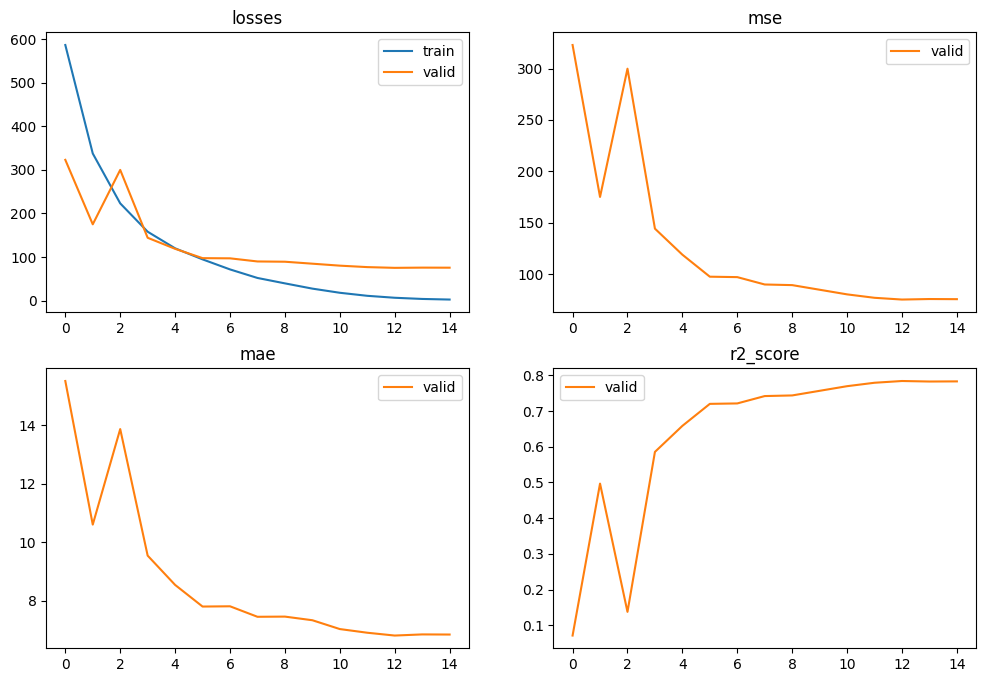

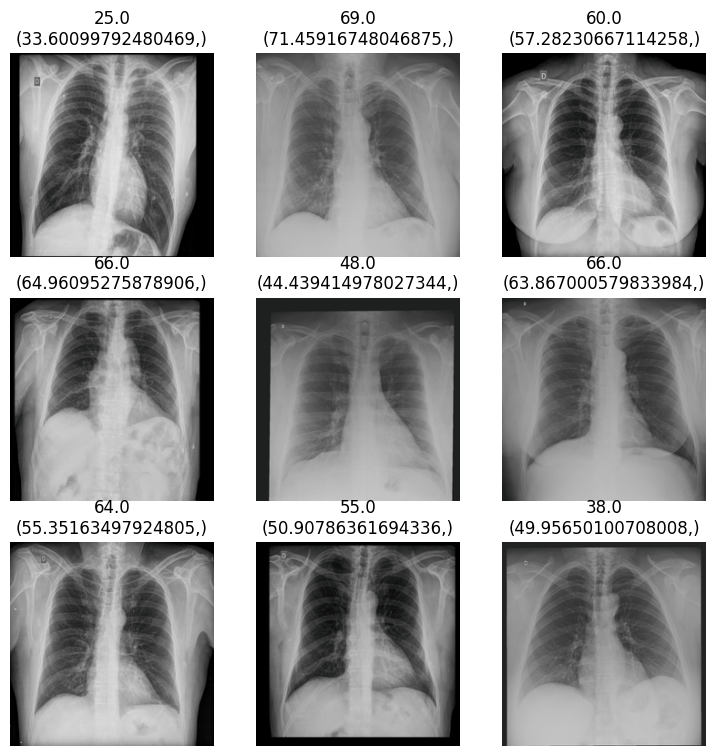

In [ ]:
epochs=15
lr=1e-3

start =time.time()
learn1.fit_one_cycle(epochs, lr_max=lr)
end = time.time()

print(f"Total training time: {end - start:.2f} seconds")
learn1.recorder.plot_metrics()
learn1.show_results()

### **Conclusion**

The model performs great. The $R^2$ coefficient is quite high, and both errors decrease succesfully. The model is not overfitted at all. We can see the training curve is smooth, so there appears to be successful learning.

---

## **3.2. ResNet34 se usa como extractor de características: Entrenamos solo la cabecera incorporada. (1.25 puntos)**



### **Explanation**

To only train the head, we need to completely freeze the model during training. The idea is to keep the pretrained weights and adjust only those in the head.

In [ ]:
custom_head = nn.Sequential(
    nn.Flatten(),
    nn.Linear(512 * 7 * 7, 1)
)


# For vision_learner, the head are all the layers after the last pooling layer
learn2 = vision_learner(dls,
                        resnet34,
                        metrics=[mse,mae,R2Score()],
                        loss_func=MSELossFlat(),
                        custom_head=custom_head,
                        pretrained=True # We want body training
)

learn2.summary()

Sequential (Input shape: 128 x 3 x 224 x 224)
Layer (type)         Output Shape         Param #    Trainable 
                     128 x 64 x 112 x 11 
Conv2d                                    9408       False     
BatchNorm2d                               128        True      
ReLU                                                           
____________________________________________________________________________
                     128 x 64 x 56 x 56  
MaxPool2d                                                      
Conv2d                                    36864      False     
BatchNorm2d                               128        True      
ReLU                                                           
Conv2d                                    36864      False     
BatchNorm2d                               128        True      
Conv2d                                    36864      False     
BatchNorm2d                               128        True      
ReLU                     

epoch,train_loss,valid_loss,mse,mae,r2_score,time
0,1149.573853,674.263611,674.263611,21.348286,-0.939873,00:12
1,571.091553,190.457642,190.457642,11.181803,0.452049,00:11
2,297.634674,120.688820,120.688820,8.706785,0.652775,00:11
3,177.795502,102.509209,102.509209,7.981368,0.705078,00:11
4,116.491508,98.375992,98.375992,7.767461,0.716970,00:11
5,84.269920,110.907990,110.907990,8.311545,0.680915,00:11
6,63.841412,91.139236,91.139236,7.459253,0.737790,00:11
7,53.315094,94.232979,94.232979,7.552666,0.728889,00:11
8,46.211105,97.223488,97.223488,7.727186,0.720286,00:11
9,45.906563,110.476074,110.476074,8.196140,0.682158,00:11


Total training time: 176.90 seconds


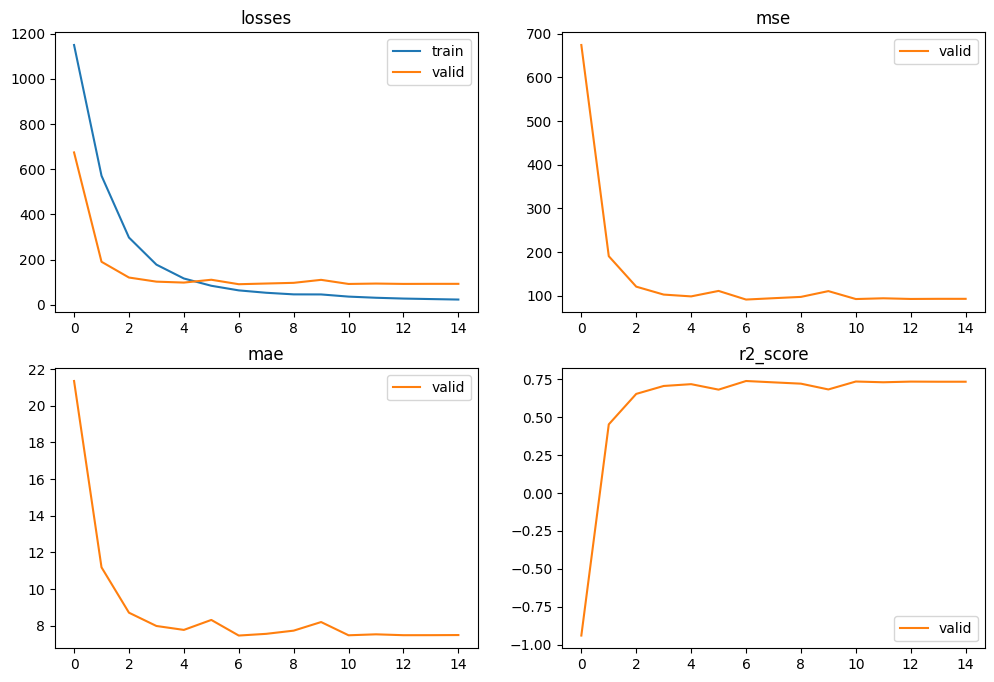

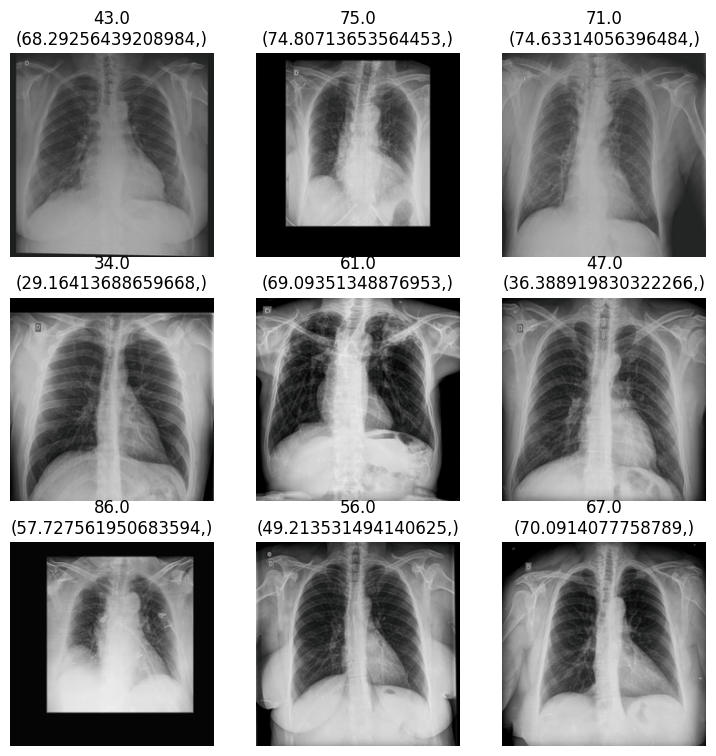

In [ ]:
epochs=15
lr=1e-3

learn2.freeze()

start =time.time()
learn2.fit_one_cycle(n_epoch=epochs,lr_max=lr)
end = time.time()

print(f"Total training time: {end - start:.2f} seconds")
learn2.recorder.plot_metrics()
learn2.show_results()


### **Conclusion**

The results are analogous to the ones of the previous model. However, convergence is much faster. It seems the backbone weights are very well fitted for our problem, so only some head training was needed.

---

### **Questions**

#### **Si no se especifica ninguna `custom_head`, ¿qué incorpora fastai por defecto?**

The custom_head added by *fastai* is not the same as the one of *Resnet34* when imported through *Pytorch*. It includes:

In [ ]:
vision_learner(dls, resnet34).model[1]

Sequential(
  (0): AdaptiveConcatPool2d(
    (ap): AdaptiveAvgPool2d(output_size=1)
    (mp): AdaptiveMaxPool2d(output_size=1)
  )
  (1): fastai.layers.Flatten(full=False)
  (2): BatchNorm1d(1024, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (3): Dropout(p=0.25, inplace=False)
  (4): Linear(in_features=1024, out_features=512, bias=False)
  (5): ReLU(inplace=True)
  (6): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (7): Dropout(p=0.5, inplace=False)
  (8): Linear(in_features=512, out_features=1, bias=False)
)

---

####  **Estamos intentando resolver un problema de regresión por medio de la reutilización de un modelo pre-entrenado en un problema de clasificación (ImageNet). ¿Tiene sentido hacerlo? ¿Por qué nos sirven pesos entrenados en clasificación para un problema de regresión? ¿No son, acaso, problemáticas muy diferentes?**

It makes total sense. Transfer learning works because the convolutional backbone learns generic visual features (edges, textures, shapes, structural patterns) that are useful for any vision task.

These low and mid-level representations are universal and do not depend on whether the final objective is classifying objects or predicting a continuous value. Only the final layer is task-specific. For regression, we simply replace *ResNet34*'s head with a new one that outputs a single value (age), while keeping the pretrained convolutional features.

---


## **3.3. Hacemos un ajuste fino (fine-tuning) de toda la red partiendo de los pesos de ImageNet. (1 punto)**

### **Explanation**

We will establish some freeze epochs to adjust only the head weights. After those are finished, we will continue adjusting all the weights, refining the pretrained weights in the backbone in addition to those in the head.

In [ ]:
custom_head = nn.Sequential(
    nn.Flatten(),
    nn.Linear(512 * 7 * 7, 1)
)


# For vision_learner, the head are all the layers after the last pooling layer
learn3 = vision_learner(dls,
                        resnet34,
                        metrics=[mse,mae,R2Score()],
                        loss_func=MSELossFlat(),
                        custom_head=custom_head,
                        pretrained=True # We want body training
)

learn3.summary()

Sequential (Input shape: 128 x 3 x 224 x 224)
Layer (type)         Output Shape         Param #    Trainable 
                     128 x 64 x 112 x 11 
Conv2d                                    9408       False     
BatchNorm2d                               128        True      
ReLU                                                           
____________________________________________________________________________
                     128 x 64 x 56 x 56  
MaxPool2d                                                      
Conv2d                                    36864      False     
BatchNorm2d                               128        True      
ReLU                                                           
Conv2d                                    36864      False     
BatchNorm2d                               128        True      
Conv2d                                    36864      False     
BatchNorm2d                               128        True      
ReLU                     

epoch,train_loss,valid_loss,mse,mae,r2_score,time
0,22.085402,93.099174,93.099174,7.503473,0.732151,00:11
1,24.607481,102.908195,102.908195,7.936288,0.703931,00:11
2,27.904476,94.920380,94.920380,7.589658,0.726912,00:12
3,29.843765,98.035004,98.035004,7.660929,0.717951,00:12
4,28.996830,105.017082,105.017082,7.946576,0.697863,00:11


epoch,train_loss,valid_loss,mse,mae,r2_score,time
0,26.831036,100.459991,100.459991,7.806504,0.710974,00:12
1,18.903811,103.741440,103.741440,7.904082,0.701533,00:11
2,19.939922,88.557320,88.557320,7.345190,0.745218,00:12
3,23.563078,76.393356,76.393356,6.789833,0.780214,00:12
4,22.342205,76.883484,76.883484,6.793031,0.778804,00:12
5,14.169022,83.978081,83.978081,7.113787,0.758393,00:11
6,9.660559,72.552055,72.552055,6.560321,0.791266,00:12
7,6.201573,71.544319,71.544319,6.575408,0.794165,00:12
8,4.362401,71.575691,71.575691,6.521003,0.794075,00:12
9,3.187076,71.018372,71.018372,6.539228,0.795678,00:12


Total training time: 181.38 seconds


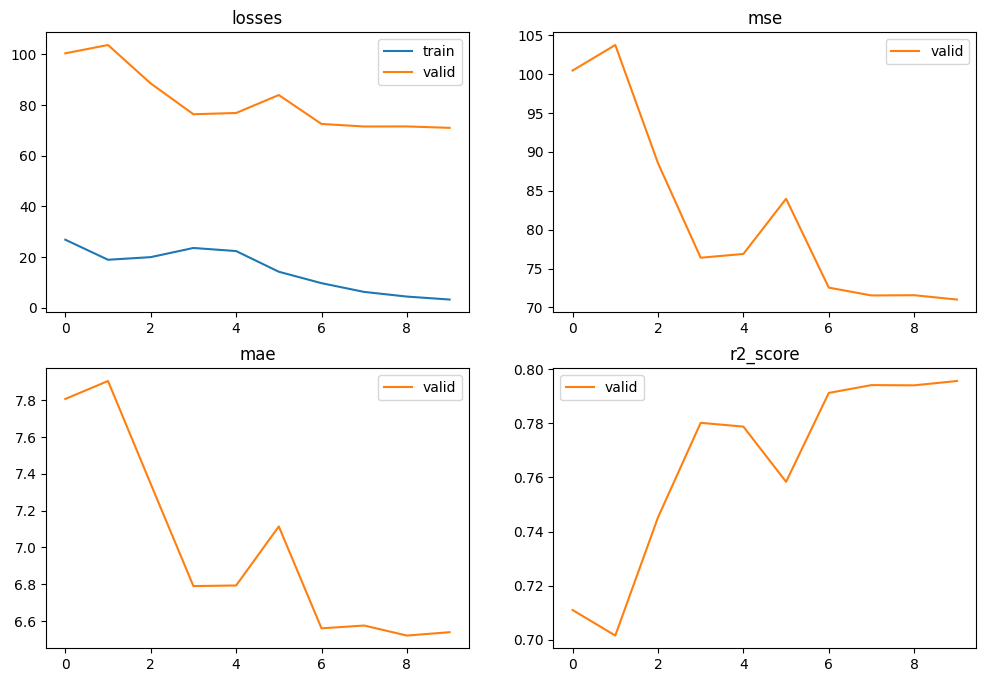

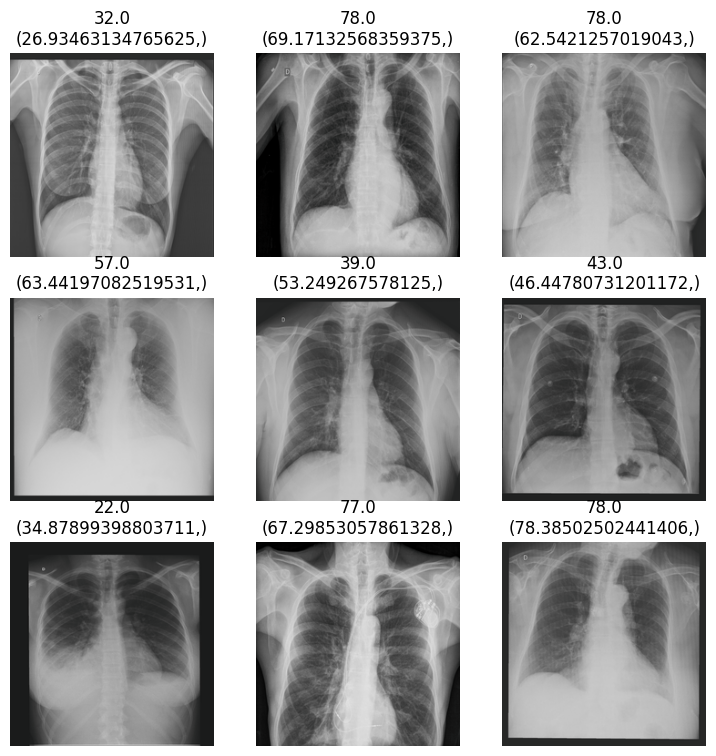

In [ ]:
epochs=10
freeze_epochs=5
lr=1e-3

start =time.time()
learn2.fine_tune(epochs=epochs,freeze_epochs=freeze_epochs,base_lr=lr)
end = time.time()

print(f"Total training time: {end - start:.2f} seconds")
learn2.recorder.plot_metrics()
learn2.show_results()


### **Conclusion**

The model seems to give similar results, although graphs are less smooth, and the model seems to be overfitted. This may be due to the learning rate that was chosen, However, I wanted to see the results for exactly the same conditions, that is, without changing what was not required in the instructions.

---

### **Questions**

#### **¿Qué conclusiones se pueden extraer en base a toda la experimentación anterior? En caso de que nos enfrentemos a un nuevo problema, ¿qué opción, u opciones, de entre las anteriores, parece a priori la más razonable? ¿Por qué?**

We can conclude the models are sensible to the election of the learning rate.

Considering the results, we could say the most reasonable option would be to just train the head of the model, as the backbone weights perform well. Besides, it grants similar results to training the whole model, but its convergence is faster.

---

## **3.4. Hacemos un ajuste fino (fine-tuning) de toda la red partiendo de los pesos de ImageNet, pero enfocando el problema como uno de clasificación. (1 punto)**

### **Explanation**

The only change in the structure of the head will be setting the output of the FC layer to the number of ages we need: $89-18+1=72$

Numero de ejemplos de entrenamiento (una vez descartados los de validacion): 5362
Numero de ejemplos de validacion: 1340


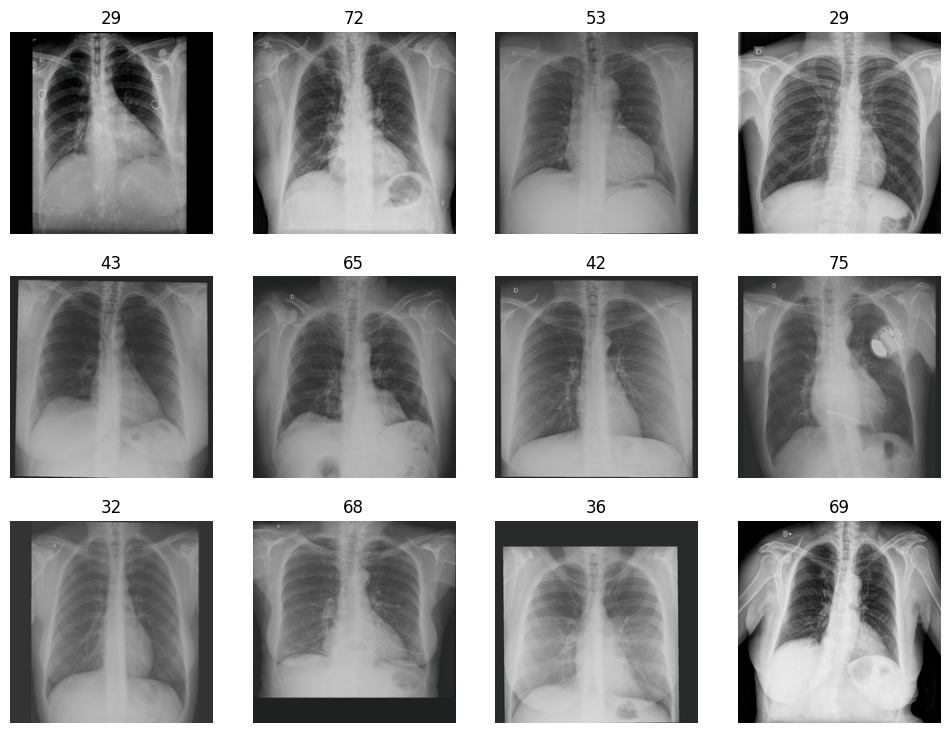

In [ ]:
dtblk = DataBlock(

    blocks=(ImageBlock, CategoryBlock), # Images have just one class
    get_items=get_image_files, # Number of images needed is already modified. Otherwise, it would obtain all
    splitter=RandomSplitter(valid_pct=0.2, seed=42), # We need 20% for validation
    get_y=label_func,
    batch_tfms=Normalize.from_stats(*imagenet_stats) # Normalizing
)

dls = dtblk.dataloaders(train_path, bs=128) # Batch size of 128 examples

dls.show_batch(max_n=12)

print('Numero de ejemplos de entrenamiento (una vez descartados los de validacion):', len(dls.train_ds))
print('Numero de ejemplos de validacion:', len(dls.valid_ds))


In [ ]:
custom_head = nn.Sequential(
    nn.Flatten(),
    nn.Linear(512 * 7 * 7, 89-18+1) # age in [18,89]
)


# For vision_learner, the head are all the layers after the last pooling layer
learn4 = vision_learner(dls,
                        resnet34,
                        metrics=[accuracy, F1Score(average='macro')],
                        loss_func=CrossEntropyLossFlat(),
                        custom_head=custom_head,
                        pretrained=True # We want weights from ImageNet
)

learn4.summary()

Sequential (Input shape: 128 x 3 x 224 x 224)
Layer (type)         Output Shape         Param #    Trainable 
                     128 x 64 x 112 x 11 
Conv2d                                    9408       False     
BatchNorm2d                               128        True      
ReLU                                                           
____________________________________________________________________________
                     128 x 64 x 56 x 56  
MaxPool2d                                                      
Conv2d                                    36864      False     
BatchNorm2d                               128        True      
ReLU                                                           
Conv2d                                    36864      False     
BatchNorm2d                               128        True      
Conv2d                                    36864      False     
BatchNorm2d                               128        True      
ReLU                     

epoch,train_loss,valid_loss,accuracy,f1_score,time
0,0.043999,9.791746,0.029851,0.023354,00:11
1,0.038511,10.297510,0.032090,0.021683,00:11
2,0.523506,14.543048,0.031343,0.020132,00:11
3,1.715607,18.773508,0.030597,0.019778,00:11
4,1.792096,19.987349,0.027612,0.018099,00:11


epoch,train_loss,valid_loss,accuracy,f1_score,time
0,0.281611,16.135498,0.036567,0.029898,00:11
1,0.145727,16.466791,0.035075,0.025871,00:12
2,0.442331,19.619444,0.045522,0.030064,00:12
3,0.797473,19.233315,0.031343,0.024252,00:11
4,0.614031,18.576952,0.038806,0.032818,00:12
5,0.352842,17.809221,0.041791,0.036861,00:12
6,0.175044,17.243378,0.038060,0.035362,00:12
7,0.082331,17.203772,0.034328,0.034769,00:11
8,0.037659,16.883165,0.038806,0.038743,00:12
9,0.017368,16.964169,0.039552,0.040747,00:12


Total training time: 179.40 seconds


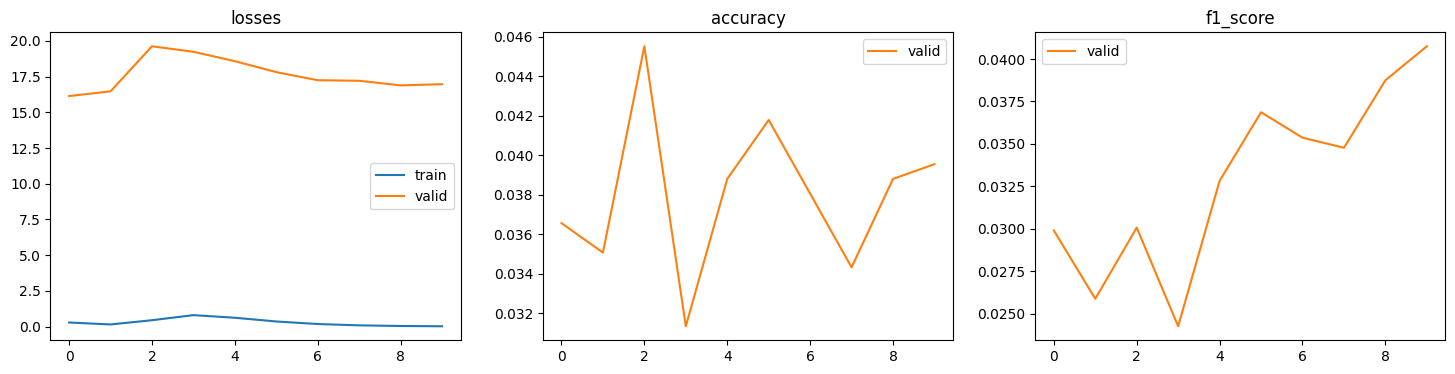

Number of Validation Examples: 1340


Validation Accuracy: 3.955223880597015%


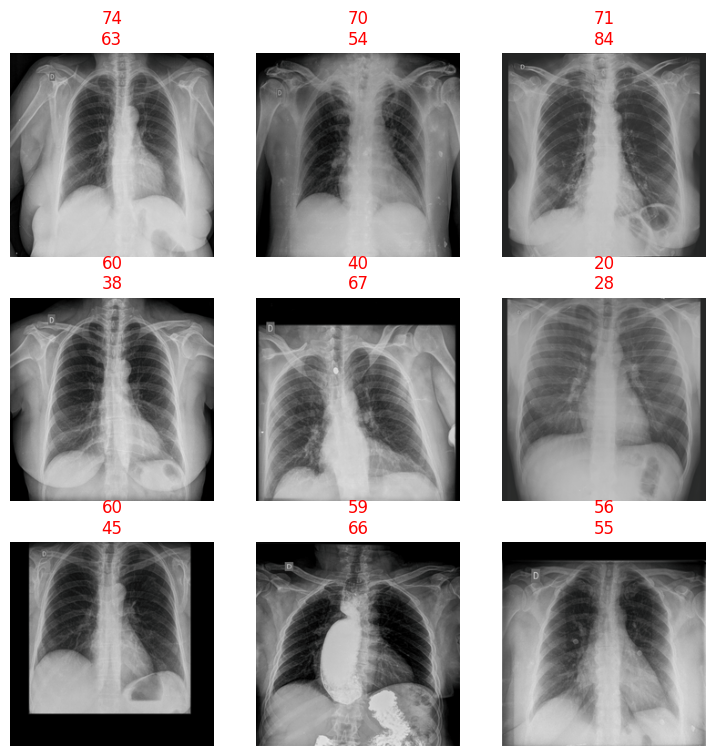

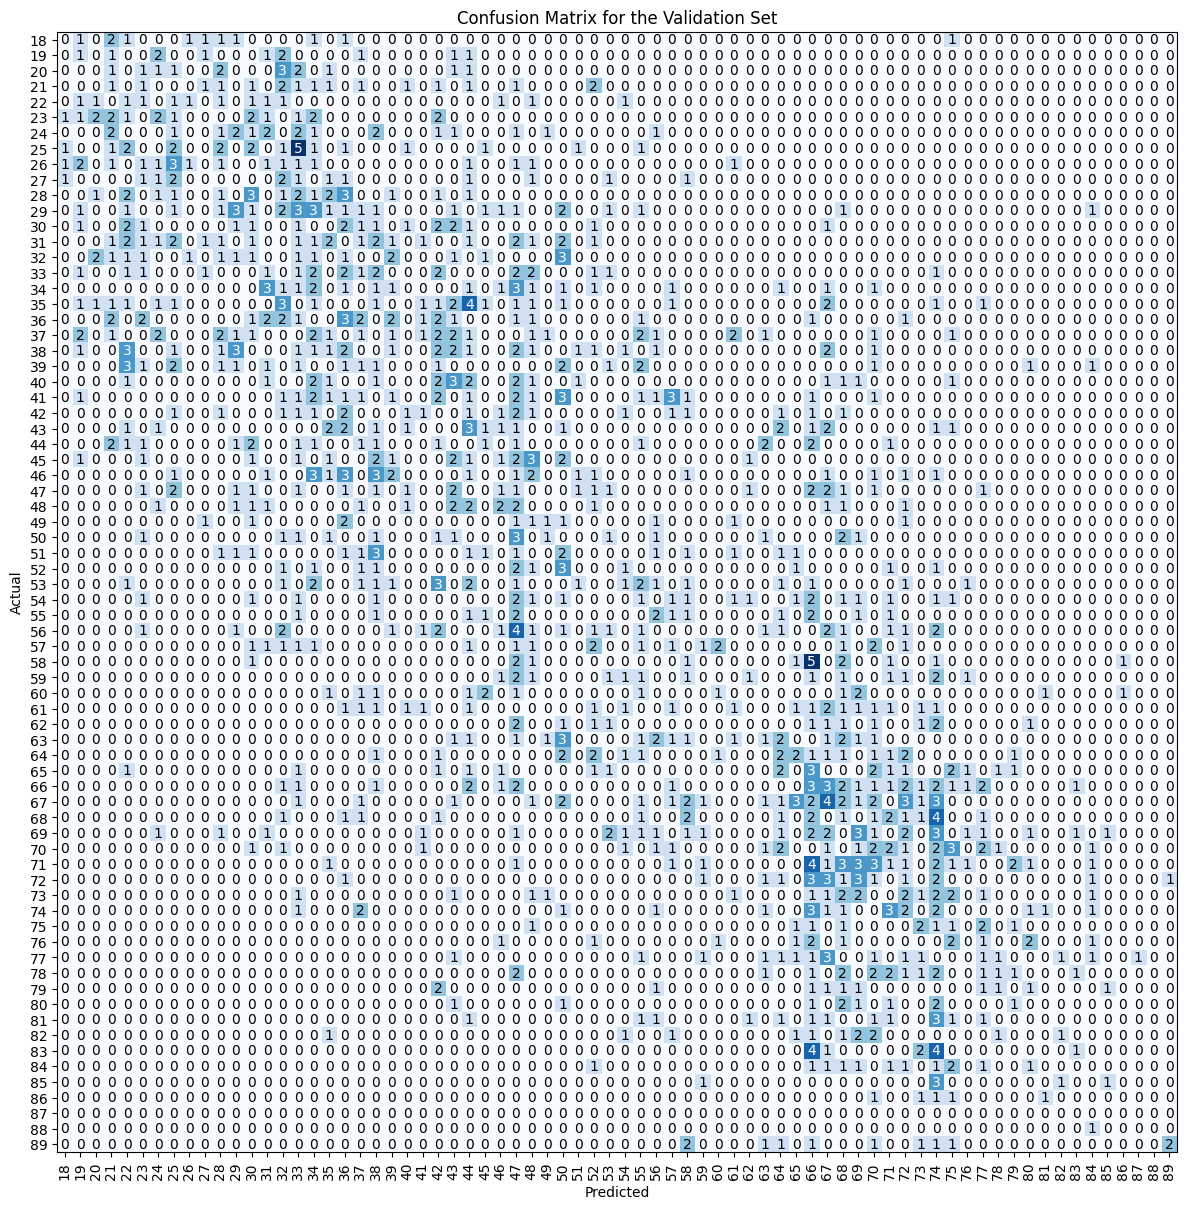

In [ ]:
epochs=10
freeze_epochs=5
lr=1e-3

start =time.time()
learn4.fine_tune(epochs=epochs,freeze_epochs=freeze_epochs,base_lr=lr)
end = time.time()

print(f"Total training time: {end - start:.2f} seconds")
learn4.recorder.plot_metrics()
learn4.show_results()
show_results(dls,learn4,'Validation')

### **Conclusion**

The model tends to underfit, and does not give a single good result: loss is too high, and accuracy and F1 Score too low.

Treating ages as classes, the ordinal structure of age is not captured. That is, every age is treated as an independent class, with no order between ages nor structure.

This is mainly a regression problem, as considering so many ages is too fine. It is very difficult for a model to capture patters without order. It would be better to consider age intervals.

---